# Comparative Framework: US, UK, and EU

This notebook brings the logic together across the three empirical notebooks.

The data layers are not identical:

- The US has metro-level occupational wages and regional price parities.
- The UK has local earnings and housing affordability, but weaker current local price parity data.
- The EU has harmonised regional income and country-level PPP / price indices, but weaker city-level cost data.

Therefore the goal is not to pretend all three are perfectly comparable. The goal is to use a common conceptual framework and keep each limitation visible.

## Common formula

The general city-premium decomposition is:

\[
\text{real gain} = \text{nominal wage premium} - \text{cost premium}
\]

Or as an index:

\[
\text{real income index} = \frac{\text{nominal income index}}{\text{cost index}}
\]

The city is financially attractive when the income premium is larger than the cost premium.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"

In [2]:
def real_income_index(nominal_income_index: float, cost_index: float) -> float:
    """Compute a real income index from nominal income and cost indices.

    Both inputs are expected to use 100 as the baseline.
    """
    if not isinstance(nominal_income_index, (int, float)):
        raise TypeError("nominal_income_index must be numeric")
    if not isinstance(cost_index, (int, float)):
        raise TypeError("cost_index must be numeric")
    if cost_index <= 0:
        raise ValueError("cost_index must be positive")
    return nominal_income_index / cost_index * 100

scenarios = pd.DataFrame(
    {
        "scenario": [
            "Low wage premium, high cost premium",
            "Moderate wage premium, moderate cost premium",
            "High wage premium, high cost premium",
            "High wage premium, low cost premium",
        ],
        "nominal_income_index": [110, 120, 150, 150],
        "cost_index": [130, 115, 140, 110],
    }
)
scenarios["real_income_index"] = scenarios.apply(
    lambda row: real_income_index(row["nominal_income_index"], row["cost_index"]), axis=1
)
scenarios["real_gain_vs_baseline"] = scenarios["real_income_index"] - 100

display(scenarios)

,scenario,nominal_income_index,cost_index,real_income_index,real_gain_vs_baseline
0,"Low wage premium, high cost premium",110,130,84.615385,-15.384615
1,"Moderate wage premium, moderate cost premium",120,115,104.347826,4.347826
2,"High wage premium, high cost premium",150,140,107.142857,7.142857
3,"High wage premium, low cost premium",150,110,136.363636,36.363636


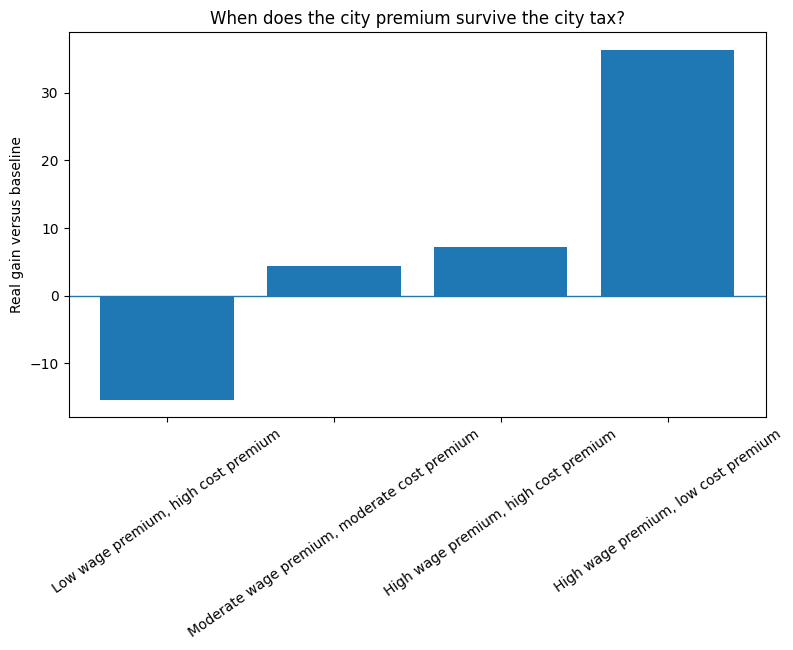

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(scenarios["scenario"], scenarios["real_gain_vs_baseline"])
ax.axhline(0, linewidth=1)
ax.set_ylabel("Real gain versus baseline")
ax.set_title("When does the city premium survive the city tax?")
ax.tick_params(axis="x", rotation=35)
plt.show()

## Load saved outputs from the empirical notebooks

Run the US, UK, and EU notebooks first. Then this notebook can read their saved outputs and create a combined comparison table.

In [4]:
def read_if_exists(path: Path) -> pd.DataFrame | None:
    """Read a CSV if it exists; otherwise return None."""
    if path.exists():
        return pd.read_csv(path)
    print(f"Missing file: {path}  -- run the corresponding notebook first.")
    return None

us = read_if_exists(OUTPUT_DIR / "us_city_wage_cost_analysis.csv")
uk = read_if_exists(OUTPUT_DIR / "uk_city_wage_cost_analysis.csv")
eu = read_if_exists(OUTPUT_DIR / "eu_region_city_proxy_income_cost_analysis.csv")

for name, df in [("US", us), ("UK", uk), ("EU", eu)]:
    if df is not None:
        print(f"\n{name} output: {df.shape[0]} rows")
        display(df.head(3))


US output: 145 rows


,area,area_title,tot_emp,a_median,a_mean,rpp_all,rpp_rent,real_a_median,real_a_mean,rent_pressure_index,oews_year,rpp_year
0,41940,"San Jose-Sunnyvale-Santa Clara, CA",1134660.0,82470.0,121160.0,110.423,211.901,74685.527472,109723.517745,1.918993,2024,2024
1,14500,"Boulder, CO",195570.0,67510.0,92590.0,105.202,157.020,64171.783806,88011.634760,1.492557,2024,2024
2,41860,"San Francisco-Oakland-Fremont, CA",2405740.0,73960.0,100140.0,115.613,194.718,63972.044666,86616.556962,1.684222,2024,2024



UK output: 337 rows


,area_code,area_name,gross_median_weekly_pay,period,area_type,period_sort,housing_affordability_ratio,annual_wage_estimate,estimated_median_house_price,required_wage_at_5x_threshold,wage_gap_to_5x_threshold,price_region,rrcpl_2016,non_housing_real_annual_wage,non_housing_city_tax
0,E09000020,Kensington and Chelsea,955.2,2025-04-30,Local Authority District,2025,21.87,49670.4,1086291.648,217258.3296,-167587.9296,London,107.0,46420.934579,3249.465421
1,E09000032,Wandsworth,916.4,2025-04-30,Local Authority District,2025,11.59,47652.8,552295.952,110459.1904,-62806.3904,NaN,NaN,NaN,NaN
2,E09000001,City of London,909.4,2018-04-18,Local Authority District,2018,16.07,47288.8,759931.016,151986.2032,-104697.4032,London,107.0,44195.140187,3093.659813



EU output: 20 rows


,city_proxy,country_name,geo,freq,unit,direct,na_item,year,household_income,country_code,...,price_level_index,real_household_income_price_adjusted,income_rank_nominal,income_rank_real,rank_change_after_price_adjustment,country_median_income,country_median_real_income,nominal_premium_vs_country_median,real_premium_vs_country_median,real_premium_pct_vs_country_median
0,Munich / Oberbayern,Germany,DE21,A,EUR_HAB,BAL,B6N,2023,34700.0,DE,...,108.3,32040.627886,2.0,1.0,1.0,27600.0,25484.764543,7100.0,6555.863343,25.724638
1,Milan / Lombardia,Italy,ITC4,A,EUR_HAB,BAL,B6N,2024,26600.0,IT,...,97.1,27394.438723,61.0,16.0,45.0,22800.0,23480.947477,3800.0,3913.491246,16.666667
2,Bucharest-Ilfov,Romania,RO32,A,EUR_HAB,BAL,B6N,2023,17600.0,RO,...,65.1,27035.330261,159.0,21.0,138.0,8400.0,12903.225806,9200.0,14132.104455,109.523810


## Put all three regions on one scale

The three datasets use different currencies, units and geographies, so absolute
numbers are not comparable. What *is* comparable is the **shape** of each
distribution: within each region we index every place to its own median (median =
100) on two measures &mdash; nominal income and price-adjusted ("real") income
&mdash; and ask how far the nominal premium is compressed by the cost adjustment.

A caveat to keep visible: the cost adjustment is not identical across regions.
The **US** uses all-items Regional Price Parities (which include housing); the
**EU** uses national price-level indices; the **UK** real index here uses only
the coarse 2016 *non-housing* regional price benchmark, with housing handled
separately in notebook&nbsp;02. So the UK's general-price adjustment is expected
to be nearly rank-preserving by construction &mdash; its real cost premium lives
in house prices, which this common index deliberately omits.

In [5]:
def normalized_frame(
    df: pd.DataFrame,
    place_col: str,
    nominal_col: str,
    real_col: str,
    region: str,
) -> pd.DataFrame:
    """Index a region's places to its own median (=100) on nominal and real income."""
    if df is None:
        return pd.DataFrame(columns=["region", "place", "nominal_index", "real_index"])
    d = df[[place_col, nominal_col, real_col]].dropna().copy()
    d.columns = ["place", "nominal", "real"]
    d["nominal_index"] = d["nominal"] / d["nominal"].median() * 100
    d["real_index"] = d["real"] / d["real"].median() * 100
    d["region"] = region
    return d[["region", "place", "nominal_index", "real_index"]]

frames = []
if us is not None:
    frames.append(normalized_frame(us, "area_title", "a_median", "real_a_median", "US metro"))
if uk is not None:
    # UK real index uses the (non-housing) regional price adjustment; housing is
    # analysed separately in notebook 02.
    frames.append(normalized_frame(uk, "area_name", "annual_wage_estimate",
                                   "non_housing_real_annual_wage", "UK local authority"))
if eu is not None:
    frames.append(normalized_frame(eu, "city_proxy", "household_income",
                                   "real_household_income_price_adjusted", "EU NUTS2 region"))

comparison_long = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
print(f"Combined places: {len(comparison_long)}")
display(comparison_long.groupby("region").size().rename("n_places").to_frame())

Combined places: 183


,n_places
region,
EU NUTS2 region,20
UK local authority,18
US metro,145


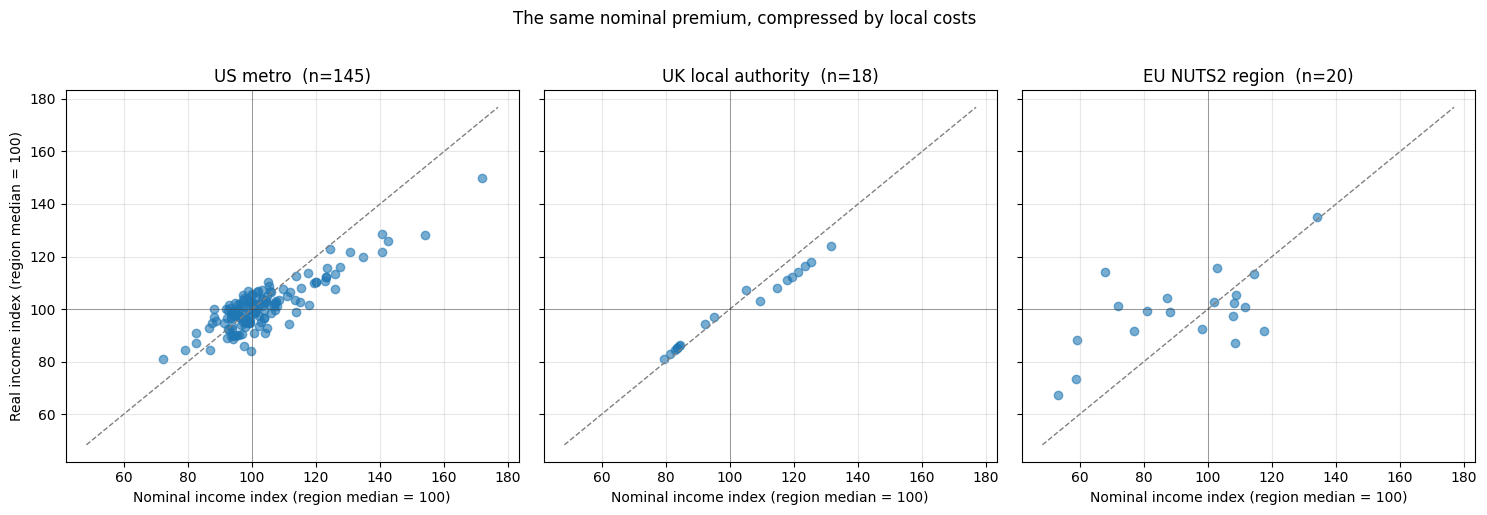

In [6]:
# Scatter: nominal index vs real index, one panel per region, shared scale.
if not comparison_long.empty:
    regions = list(comparison_long["region"].unique())
    fig, axes = plt.subplots(1, len(regions), figsize=(5 * len(regions), 5), sharex=True, sharey=True)
    if len(regions) == 1:
        axes = [axes]
    lo = min(comparison_long["nominal_index"].min(), comparison_long["real_index"].min()) - 5
    hi = max(comparison_long["nominal_index"].max(), comparison_long["real_index"].max()) + 5
    for ax, region in zip(axes, regions):
        g = comparison_long[comparison_long["region"] == region]
        ax.scatter(g["nominal_index"], g["real_index"], alpha=0.6)
        ax.plot([lo, hi], [lo, hi], linestyle="--", color="grey", linewidth=1)
        ax.axhline(100, color="black", linewidth=0.6, alpha=0.4)
        ax.axvline(100, color="black", linewidth=0.6, alpha=0.4)
        ax.set_title(f"{region}  (n={len(g)})")
        ax.set_xlabel("Nominal income index (region median = 100)")
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel("Real income index (region median = 100)")
    fig.suptitle("The same nominal premium, compressed by local costs", y=1.02)
    plt.tight_layout()
    plt.show()


In [7]:
# How much does the cost adjustment reshuffle and compress the premium?
def region_summary(g: pd.DataFrame) -> pd.Series:
    spearman = g["nominal_index"].corr(g["real_index"], method="spearman")
    top = g[g["nominal_index"] >= g["nominal_index"].quantile(0.9)]
    return pd.Series({
        "n_places": len(g),
        "rank_corr_nominal_vs_real": round(spearman, 3),
        "top10pct_nominal_index": round(top["nominal_index"].mean(), 1),
        "top10pct_real_index": round(top["real_index"].mean(), 1),
        "premium_compression": round(top["nominal_index"].mean() - top["real_index"].mean(), 1),
    })

if not comparison_long.empty:
    summary = comparison_long.groupby("region").apply(region_summary, include_groups=False)
    display(summary)
    print(
        "rank_corr close to 1 => the cost adjustment barely changes the ranking.\n"
        "premium_compression = how many index points the top-decile nominal\n"
        "premium loses after the cost adjustment (higher = more of the premium\n"
        "is eaten by local prices)."
    )


,n_places,rank_corr_nominal_vs_real,top10pct_nominal_index,top10pct_real_index,premium_compression
region,,,,,
EU NUTS2 region,20.0,0.438,125.7,113.5,12.2
UK local authority,18.0,0.998,128.3,120.9,7.5
US metro,145.0,0.713,134.1,120.5,13.6


rank_corr close to 1 => the cost adjustment barely changes the ranking.
premium_compression = how many index points the top-decile nominal
premium loses after the cost adjustment (higher = more of the premium
is eaten by local prices).


## Comparative conclusion

Putting the three regions on a common median-indexed scale shows the same
mechanism everywhere, with a different dominant cost channel in each.

**1. The nominal premium is partly an illusion in every region.** The top-decile
(highest-nominal) places lose income-index points once local costs are netted
out: roughly **&minus;14** points in US metros (134 &rarr; 120), **&minus;12** in
EU NUTS2 regions (126 &rarr; 113), and **&minus;7** in UK authorities on the
*non-housing* adjustment alone (128 &rarr; 121). A nominal lead is necessary but
never sufficient.

**2. The cost adjustment reshuffles rankings most in the EU, least (visibly) in
the UK.** Spearman rank correlation between nominal and real income is **0.44**
for EU regions (national price levels span ~65 to ~140, so the order is scrambled
heavily), **0.71** for US metros, and **0.998** for the UK. The UK number is a
*warning, not reassurance*: its regional general-price index is nearly flat, so
it cannot move the ranking &mdash; the UK's real cost premium hides in house
prices, which this common index excludes by design.

**3. Each region's "city tax" runs through a different channel.**

| Region | Dominant cost channel | Flagship example (nominal &rarr; real index) |
|---|---|---|
| US metros | All-items local prices, rent-heavy on the coasts | San Francisco **154 &rarr; 128** |
| EU regions | Cross-**country** price levels | Copenhagen **117 &rarr; 92** (falls *below* its median) |
| UK authorities | **House prices**, not general prices | Westminster 119 &rarr; 112 *non-housing* &mdash; but a 16&times; vs ~7&times; affordability gap dwarfs that |

**4. The unifying answer.** Across all three regions, "moving to the big, high-
paying place" raises nominal income reliably and real living standards only
*conditionally*. The condition differs by geography &mdash; survive the local
*rent* (US), survive the national *price level* (EU), or survive *house prices*
(UK) &mdash; and, as the US notebook shows, it differs by **occupation** and, as
the UK notebook shows, by **housing tenure**. A cautious, conditional verdict is
the honest one: the city premium is real for high-skill workers in genuinely
high-wage cities, and small, zero or negative for median earners where costs
(especially housing) absorb the raise.